#### Importing the necessary libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


##### Loading the data

In [3]:
#loading the dataset
data = pd.read_csv('medical_insurance_data\medical_insurance.csv')

In [4]:
#reading the first 5 rows of the dataset
data.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [5]:
#Checking the data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [6]:
data['household_size'].value_counts()

2    38772
3    27036
1    19133
4    11007
5     3199
6      708
7      129
8       13
9        3
Name: household_size, dtype: int64

In [7]:
#checking for missing values
data.isnull().sum()

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [8]:
#Checking for duplicates
data.duplicated().sum()

0

## Exploratory Data Analysis

In [9]:
#dropping columns that will not be used in analysis
data = data.drop(columns=['person_id'])

In [10]:
data['annual_premium'].describe()

count    100000.000000
mean        582.320040
std         399.583722
min         211.670000
25%         352.070000
50%         463.585000
75%         666.697500
max       10962.550000
Name: annual_premium, dtype: float64

In [11]:
data['income'].value_counts()

21300.0     220
23700.0     218
21400.0     211
20800.0     211
26400.0     210
           ... 
239500.0      1
318800.0      1
314900.0      1
419000.0      1
163000.0      1
Name: income, Length: 2987, dtype: int64

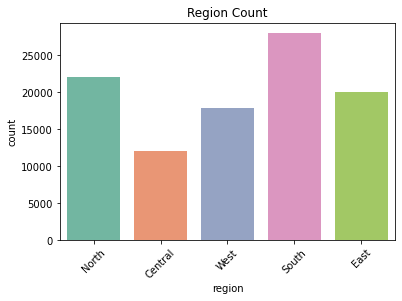

In [12]:
#medical insurance holders by region 
sns.countplot(x='region', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title('Region Count')
plt.show()

The Southern region has the highest number of individuals with a medical insurance cover

In [13]:
#defining categorical and numerical columns
categorical_cols = data.select_dtypes(include=['object']).columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

Most features seem to have a low correlation with the target vairiable(annual premium)

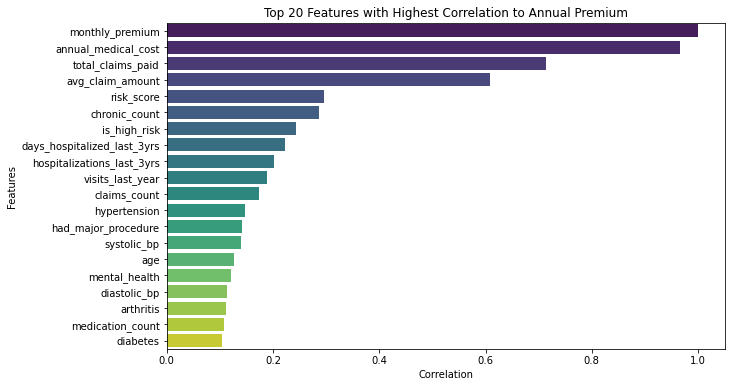

In [15]:
#top 20 features that have the highest correlation with annual premium
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation(numerical_cols).values[:20], y=correlation(numerical_cols).index[:20], palette='viridis')
plt.title('Top 20 Features with Highest Correlation to Annual Premium')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

The monthly premium, annual medical cost and total claims paid are among the factors that most influence annual premium paid.

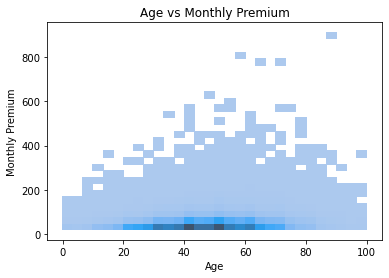

In [36]:
# visualizing the relationship between age and monthly premium
sns.histplot(data=data, x='age', y='monthly_premium', bins=30)
plt.title('Age vs Monthly Premium')
plt.xlabel('Age')
plt.ylabel('Monthly Premium')
plt.show()

In [37]:
#correlation between numerical features and annual premium
def correlation(numerical_cols):
    numerical_cols = numerical_cols.copy()
    return data[numerical_cols].corrwith(data['annual_premium']).drop('annual_premium').sort_values(ascending=False)

correlation(numerical_cols)

monthly_premium                1.000000
annual_medical_cost            0.965415
total_claims_paid              0.713764
avg_claim_amount               0.608786
risk_score                     0.295859
chronic_count                  0.286698
is_high_risk                   0.244012
days_hospitalized_last_3yrs    0.222634
hospitalizations_last_3yrs     0.201935
visits_last_year               0.188857
claims_count                   0.173622
hypertension                   0.147329
had_major_procedure            0.142128
systolic_bp                    0.139419
age                            0.127473
mental_health                  0.121460
diastolic_bp                   0.114142
arthritis                      0.111821
medication_count               0.108598
diabetes                       0.104391
hba1c                          0.081799
asthma                         0.079231
cardiovascular_disease         0.076415
proc_surgery_count             0.074306
copd                           0.066949
